In [224]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import random
import numpy as np
from datetime import date
import time
from sklearn.preprocessing import StandardScaler

In [225]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [226]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        name = torch.cuda.get_device_name(0)
        print(f"Using GPU: {name}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device
device = get_device()

Using GPU: NVIDIA GeForce RTX 4060


In [227]:
#lets set some hyperparameters for rnn/lstm/gru

batch_size = 264
hidden_size = 128
dropout = 0.2
num_epochs = 500
learning_rate = 0.001
clip_grad_norm = 1.0
NUM_WORKERS=4

In [228]:
# tesla_data = yf.download('TSLA', start='2020-01-01', end='2026-03-01')
# apple_data = yf.download('AAPL', start='2020-01-01', end='2026-03-01')
# tesla_data.to_csv('./data/tesla_data.csv')
# apple_data.to_csv('./data/apple_data.csv')


In [229]:
tesla_data = pd.read_csv('./data/tesla_data.csv')
apple_data = pd.read_csv('./data/apple_data.csv')

print("Tesla Data:")
print(tesla_data.head())
print("\nApple Data:")
print(apple_data.head())

Tesla Data:
         Date      Close       High        Low       Open     Volume
0  2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
1  2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2  2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
3  2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
4  2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500

Apple Data:
         Date      Close       High        Low       Open     Volume
0  2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
1  2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2  2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
3  2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
4  2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


In [230]:
# explore the data
print(tesla_data.describe())
print(tesla_data.info())
# let's check if there is any null data 
print(tesla_data.isnull().sum())
print(apple_data.isnull().sum())


             Close         High          Low         Open        Volume
count  1547.000000  1547.000000  1547.000000  1547.000000  1.547000e+03
mean    241.968565   247.362613   236.357720   242.043730  1.194234e+08
std     100.534210   102.541549    98.585532   100.735940  7.658516e+07
min      24.081333    26.990667    23.367332    24.980000  2.940180e+07
25%     184.389999   187.409996   180.476669   184.570000  7.363565e+07
50%     237.306671   241.800003   232.600006   236.860001  9.843990e+07
75%     300.005005   307.135010   292.476669   300.024994  1.359664e+08
max     489.880005   498.829987   485.329987   489.880005  9.140820e+08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547 entries, 0 to 1546
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1547 non-null   object 
 1   Close   1547 non-null   float64
 2   High    1547 non-null   float64
 3   Low     1547 non-null   float64
 4   Open    1547 non-nu

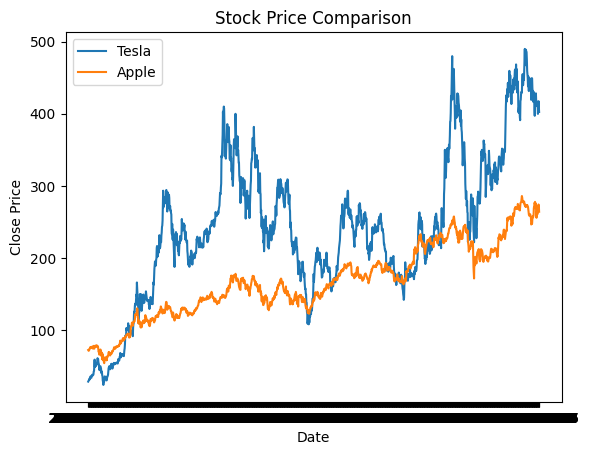

In [231]:
# lets compare the price of both stock overtime
sns.lineplot(data=tesla_data, x="Date", y="Close", label="Tesla")
sns.lineplot(data=apple_data, x="Date", y = "Close", label="Apple")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Price Comparison")
plt.legend()
plt.show()


In [232]:
# encoding the date column to datetime format
tesla_data['Date'] = pd.to_datetime(tesla_data['Date'])
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
# extracting components of date
tesla_data["Year"] = tesla_data['Date'].dt.year
tesla_data["Month"] = tesla_data['Date'].dt.month
tesla_data["Day"] = tesla_data['Date'].dt.day
tesla_data["weekday"] = tesla_data['Date'].dt.weekday
tesla_data["quarter"] = tesla_data['Date'].dt.quarter
apple_data["Year"] = apple_data['Date'].dt.year
apple_data["Month"] = apple_data['Date'].dt.month
apple_data["Day"] = apple_data['Date'].dt.day
apple_data["weekday"] = apple_data['Date'].dt.weekday
apple_data["quarter"] = apple_data['Date'].dt.quarter
# cylindrical encoding of month day weekday and quarter
tesla_data["month_sin"] = np.sin(2 * np.pi * tesla_data["Month"] / 12)
tesla_data["month_cos"] = np.cos(2 * np.pi * tesla_data["Month"] / 12)
tesla_data["day_sin"] = np.sin(2 * np.pi * tesla_data["Day"] / 31)
tesla_data["day_cos"] = np.cos(2 * np.pi * tesla_data["Day"] / 31)
tesla_data["weekday_sin"] = np.sin(2 * np.pi * tesla_data["weekday"] / 7)
tesla_data["weekday_cos"] = np.cos(2 * np.pi * tesla_data["weekday"] / 7)
tesla_data["quarter_sin"] = np.sin(2 * np.pi * tesla_data["quarter"] / 4)
tesla_data["quarter_cos"] = np.cos(2 * np.pi * tesla_data["quarter"] / 4)
apple_data["month_sin"] = np.sin(2 * np.pi * apple_data["Month"] / 12)
apple_data["month_cos"] = np.cos(2 * np.pi * apple_data["Month"] / 12)
apple_data["day_sin"] = np.sin(2 * np.pi * apple_data["Day"] / 31)
apple_data["day_cos"] = np.cos(2 * np.pi * apple_data["Day"] / 31)
apple_data["weekday_sin"] = np.sin(2 * np.pi * apple_data["weekday"] / 7)
apple_data["weekday_cos"] = np.cos(2 * np.pi * apple_data["weekday"] / 7)
apple_data["quarter_sin"] = np.sin(2 * np.pi * apple_data["quarter"] / 4)
apple_data["quarter_cos"] = np.cos(2 * np.pi * apple_data["quarter"] / 4)

tesla_data.drop(columns=["Date", "Year", "Month", "Day", "weekday", "quarter"], inplace=True)
apple_data.drop(columns=["Date", "Year", "Month", "Day", "weekday", "quarter"], inplace=True)
tesla_data.head()
apple_data.head()

,Close,High,Low,Open,Volume,month_sin,month_cos,day_sin,day_cos,weekday_sin,weekday_cos,quarter_sin,quarter_cos
0,72.400520,72.460784,71.156682,71.409785,135480400,0.5,0.866025,0.394356,0.918958,0.433884,-0.900969,1.0,6.123234e-17
1,71.696640,72.455958,71.472462,71.629145,146322800,0.5,0.866025,0.571268,0.820763,-0.433884,-0.900969,1.0,6.123234e-17
2,72.267944,72.306514,70.568518,70.819216,118387200,0.5,0.866025,0.937752,0.347305,0.000000,1.000000,1.0,6.123234e-17
3,71.928062,72.533103,71.708703,72.277586,108872000,0.5,0.866025,0.988468,0.151428,0.781831,0.623490,1.0,6.123234e-17
4,73.085106,73.386423,71.631552,71.631552,132079200,0.5,0.866025,0.998717,-0.050649,0.974928,-0.222521,1.0,6.123234e-17


In [233]:
# lets standardize the data
scalar = StandardScaler()
tesla_data_scaled = scalar.fit_transform(tesla_data)
apple_data_scaled = scalar.fit_transform(apple_data)

# Create sequences for time series forecasting
def create_sequences(data, seq_length=1):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])  # predict first column (Close price)
    return np.array(X), np.array(y)

seq_length = 1
X_tesla, y_tesla = create_sequences(tesla_data_scaled, seq_length)
X_apple, y_apple = create_sequences(apple_data_scaled, seq_length)

# Convert to tensors ON DEVICE
X_tesla_tensor = torch.FloatTensor(X_tesla).to(device)
y_tesla_tensor = torch.FloatTensor(y_tesla).to(device)
X_apple_tensor = torch.FloatTensor(X_apple).to(device)
y_apple_tensor = torch.FloatTensor(y_apple).to(device)

# Create TensorDatasets
tesla_dataset = TensorDataset(X_tesla_tensor, y_tesla_tensor)
apple_dataset = TensorDataset(X_apple_tensor, y_apple_tensor)

# Split datasets
train_size_tesla = int(0.8 * len(tesla_dataset))
test_size_tesla = len(tesla_dataset) - train_size_tesla
tesla_train_dataset, tesla_test_dataset = random_split(tesla_dataset, [train_size_tesla, test_size_tesla])

train_size_apple = int(0.8 * len(apple_dataset))
test_size_apple = len(apple_dataset) - train_size_apple
apple_train_dataset, apple_test_dataset = random_split(apple_dataset, [train_size_apple, test_size_apple])

# Create dataloaders
tesla_train_loader = DataLoader(
    tesla_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
apple_train_loader = DataLoader(
    apple_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
tesla_test_loader = DataLoader(
    tesla_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
apple_test_loader = DataLoader(
    apple_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [234]:
class RecurrentLM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=4, num_layers=2, dropout=0.2, rnn_type='RNN'):
        super(RecurrentLM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        if rnn_type == 'RNN':
            self.rnn = nn.RNN(
                input_size, hidden_size, num_layers,
                batch_first=True, dropout=dropout, nonlinearity='tanh'
            )
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(
                input_size, hidden_size, num_layers,
                batch_first=True, dropout=dropout
            )
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(
                input_size, hidden_size, num_layers,
                batch_first=True, dropout=dropout
            )
        else:
            raise ValueError("Invalid rnn_type. Choose from 'RNN', 'LSTM', or 'GRU'.")

        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.fc.weight, -0.1, 0.1)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, hidden=None):
        if self.rnn_type == 'LSTM':
            out, (h_n, c_n) = self.rnn(x, hidden)
            hidden = (h_n, c_n)
        else:
            out, hidden = self.rnn(x, hidden)

        out = self.dropout(out)
        out = self.fc(out[:, -1, :])  # [batch_size, 4]
        return out, hidden

    def _init_hidden(self, batch_size):
        if self.rnn_type == 'LSTM':
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            return (h_0, c_0)
        else:
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
            return h_0
    


In [235]:
def create_model(rnn_type):
    model = RecurrentLM(input_size=tesla_data_scaled.shape[1], hidden_size=hidden_size, output_size=1, num_layers=2, dropout=dropout, rnn_type=rnn_type).to(device)
    return model
torch.manual_seed(seed)
rnn_model = create_model('RNN')
lstm_model = create_model('LSTM')
gru_model = create_model('GRU')

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"RNN Model Parameters: {count_parameters(rnn_model)}")
print(f"LSTM Model Parameters: {count_parameters(lstm_model)}")
print(f"GRU Model Parameters: {count_parameters(gru_model)}")
print(f"\n RNN Model Architecture:\n{rnn_model}")

RNN Model Parameters: 51457
LSTM Model Parameters: 205441
GRU Model Parameters: 154113

 RNN Model Architecture:
RecurrentLM(
  (rnn): RNN(13, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [236]:
# loss function - use MSELoss for regression (not CrossEntropyLoss which is for classification)
criterion = nn.MSELoss()


def make_optimizer(model):
    return optim.Adam(model.parameters(), lr=learning_rate)

rnn_optimizer = make_optimizer(rnn_model)
lstm_optimizer = make_optimizer(lstm_model)
gru_optimizer = make_optimizer(gru_model)
print("Optimizers: Adam for all models with learning rate =", learning_rate)

Optimizers: Adam for all models with learning rate = 0.001


In [237]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0
    start_time = time.time()
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(x_batch)
        # For regression, logits shape is [batch_size, 1] and y_batch is [batch_size]
        # We need to squeeze logits to match y_batch shape
        logits = logits.squeeze(-1)  # Remove the extra dimension
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches
    # For MSE loss, we report RMSE as perplexity
    rmse = np.sqrt(avg_loss)
    elapsed_time = time.time() - start_time
    return avg_loss, rmse, elapsed_time

In [238]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    n_batches = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = model(x_batch)
            logits = logits.squeeze(-1)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            n_batches += 1
    avg_loss = total_loss / n_batches
    rmse = np.sqrt(avg_loss)
    return avg_loss, rmse

In [239]:
history ={
    "RNN": {"train_loss": [], "train_perplexity": [], "train_time": [], "test_loss": [], "test_perplexity": []},
    "LSTM":  {"train_loss": [], "train_perplexity": [], "train_time": [], "test_loss": [], "test_perplexity": []},
    "GRU":  {"train_loss": [], "train_perplexity": [], "train_time": [], "test_loss": [], "test_perplexity": []}
}

def train_model_tesla(model, optimizer, model_name, num_epochs):
    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")
    print(f"  {'Epoch':>5} | {'Train Loss':>10} | {'Train PPL':>10} | {'Val Loss':>9} | {'Val PPL':>8} | {'Time':>6}")
    print(f"  {'-'*60}")
    for epoch in range(1, num_epochs + 1):
        train_loss, train_ppl, train_time = train_epoch(model, tesla_train_loader, optimizer, criterion, device)
        test_loss, test_ppl = evaluate(model, tesla_test_loader, criterion, device)
        history[model_name]["train_loss"].append(train_loss)
        history[model_name]["train_perplexity"].append(train_ppl)
        history[model_name]["train_time"].append(train_time)
        history[model_name]["test_loss"].append(test_loss)
        history[model_name]["test_perplexity"].append(test_ppl)
        print(f"  {epoch:5d} | {train_loss:10.4f} | {train_ppl:10.4f} | {test_loss:9.4f} | {test_ppl:8.4f} | {train_time:6.2f}s")

def train_model_apple(model, optimizer, model_name, num_epochs):
    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")
    print(f"  {'Epoch':>5} | {'Train Loss':>10} | {'Train PPL':>10} | {'Val Loss':>9} | {'Val PPL':>8} | {'Time':>6}")
    print(f"  {'-'*60}")
    for epoch in range(1, num_epochs + 1):
        train_loss, train_ppl, train_time = train_epoch(model, apple_train_loader, optimizer, criterion, device)
        test_loss, test_ppl = evaluate(model, apple_test_loader, criterion, device)
        history[model_name]["train_loss"].append(train_loss)
        history[model_name]["train_perplexity"].append(train_ppl)
        history[model_name]["train_time"].append(train_time)
        history[model_name]["test_loss"].append(test_loss)
        history[model_name]["test_perplexity"].append(test_ppl)
        print(f"  {epoch:5d} | {train_loss:10.4f} | {train_ppl:10.4f} | {test_loss:9.4f} | {test_ppl:8.4f} | {train_time:6.2f}s")
print(" train_model() function ready. Starting training now...")
print(f"   Epochs       : {num_epochs}")
print(f"   Device       : {device}")
print(f"   Batch size   : {batch_size}")
print(f"   Train batches: {len(tesla_train_loader)} (Tesla), {len(apple_train_loader)} (Apple)")
  

 train_model() function ready. Starting training now...
   Epochs       : 500
   Device       : cuda
   Batch size   : 264
   Train batches: 5 (Tesla), 5 (Apple)


In [240]:

train_model_apple(rnn_model, rnn_optimizer, "RNN", num_epochs)


  Training RNN
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     0.7493 |     0.8656 |    0.2513 |   0.5013 |   0.02s
      2 |     0.1694 |     0.4116 |    0.0207 |   0.1440 |   0.01s
      3 |     0.0633 |     0.2517 |    0.0737 |   0.2716 |   0.01s
      4 |     0.0703 |     0.2651 |    0.0203 |   0.1423 |   0.01s
      5 |     0.0290 |     0.1704 |    0.0158 |   0.1259 |   0.01s
      6 |     0.0312 |     0.1767 |    0.0080 |   0.0893 |   0.01s
      7 |     0.0212 |     0.1457 |    0.0102 |   0.1009 |   0.01s
      8 |     0.0235 |     0.1533 |    0.0070 |   0.0837 |   0.02s
      9 |     0.0175 |     0.1324 |    0.0060 |   0.0777 |   0.02s
     10 |     0.0191 |     0.1382 |    0.0056 |   0.0751 |   0.02s
     11 |     0.0178 |     0.1332 |    0.0053 |   0.0726 |   0.02s
     12 |     0.0179 |     0.1337 |    0.0052 |   0.0720 |   0.02s
     13 |     0.0165 |     0.1286 |    0.0042 |   0

In [241]:
train_model_apple(lstm_model, lstm_optimizer, "LSTM", num_epochs)


  Training LSTM
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     1.0081 |     1.0040 |    0.7465 |   0.8640 |   0.02s
      2 |     0.9320 |     0.9654 |    0.6763 |   0.8224 |   0.02s
      3 |     0.8268 |     0.9093 |    0.5746 |   0.7580 |   0.01s
      4 |     0.6729 |     0.8203 |    0.4382 |   0.6620 |   0.01s
      5 |     0.4838 |     0.6955 |    0.2797 |   0.5288 |   0.01s
      6 |     0.2787 |     0.5279 |    0.1343 |   0.3664 |   0.02s
      7 |     0.1237 |     0.3517 |    0.0499 |   0.2234 |   0.01s
      8 |     0.0553 |     0.2351 |    0.0428 |   0.2068 |   0.01s
      9 |     0.0559 |     0.2364 |    0.0444 |   0.2106 |   0.01s
     10 |     0.0448 |     0.2116 |    0.0257 |   0.1602 |   0.01s
     11 |     0.0270 |     0.1644 |    0.0163 |   0.1276 |   0.01s
     12 |     0.0242 |     0.1554 |    0.0150 |   0.1223 |   0.01s
     13 |     0.0231 |     0.1520 |    0.0131 |   

In [242]:
train_model_apple(gru_model, gru_optimizer, "GRU", num_epochs)


  Training GRU
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     0.9475 |     0.9734 |    0.6225 |   0.7890 |   0.02s
      2 |     0.7046 |     0.8394 |    0.4192 |   0.6475 |   0.02s
      3 |     0.4318 |     0.6571 |    0.2013 |   0.4486 |   0.01s
      4 |     0.1801 |     0.4244 |    0.0530 |   0.2303 |   0.01s
      5 |     0.0558 |     0.2362 |    0.0461 |   0.2147 |   0.01s
      6 |     0.0649 |     0.2548 |    0.0576 |   0.2401 |   0.01s
      7 |     0.0506 |     0.2250 |    0.0274 |   0.1656 |   0.01s
      8 |     0.0280 |     0.1672 |    0.0158 |   0.1257 |   0.01s
      9 |     0.0257 |     0.1604 |    0.0140 |   0.1185 |   0.01s
     10 |     0.0242 |     0.1554 |    0.0088 |   0.0940 |   0.01s
     11 |     0.0191 |     0.1384 |    0.0068 |   0.0826 |   0.01s
     12 |     0.0161 |     0.1269 |    0.0093 |   0.0964 |   0.01s
     13 |     0.0170 |     0.1305 |    0.0087 |   0

In [243]:
train_model_tesla(rnn_model, rnn_optimizer, "RNN", num_epochs)


  Training RNN
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     0.0134 |     0.1156 |    0.0093 |   0.0964 |   0.02s
      2 |     0.0148 |     0.1218 |    0.0092 |   0.0961 |   0.02s
      3 |     0.0137 |     0.1170 |    0.0091 |   0.0956 |   0.02s
      4 |     0.0139 |     0.1177 |    0.0097 |   0.0985 |   0.02s
      5 |     0.0143 |     0.1195 |    0.0091 |   0.0955 |   0.01s
      6 |     0.0137 |     0.1170 |    0.0095 |   0.0973 |   0.02s
      7 |     0.0138 |     0.1173 |    0.0092 |   0.0958 |   0.02s
      8 |     0.0137 |     0.1169 |    0.0093 |   0.0966 |   0.02s
      9 |     0.0139 |     0.1179 |    0.0095 |   0.0973 |   0.02s
     10 |     0.0143 |     0.1196 |    0.0093 |   0.0962 |   0.01s
     11 |     0.0142 |     0.1192 |    0.0097 |   0.0985 |   0.02s
     12 |     0.0136 |     0.1167 |    0.0099 |   0.0997 |   0.02s
     13 |     0.0137 |     0.1169 |    0.0095 |   0

In [244]:
train_model_tesla(lstm_model, lstm_optimizer, "LSTM", num_epochs)


  Training LSTM
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     0.0135 |     0.1162 |    0.0093 |   0.0965 |   0.02s
      2 |     0.0133 |     0.1153 |    0.0093 |   0.0964 |   0.02s
      3 |     0.0134 |     0.1156 |    0.0097 |   0.0986 |   0.02s
      4 |     0.0130 |     0.1141 |    0.0098 |   0.0989 |   0.02s
      5 |     0.0134 |     0.1156 |    0.0100 |   0.1001 |   0.02s
      6 |     0.0133 |     0.1155 |    0.0097 |   0.0985 |   0.01s
      7 |     0.0139 |     0.1180 |    0.0097 |   0.0985 |   0.02s
      8 |     0.0134 |     0.1156 |    0.0100 |   0.1000 |   0.02s
      9 |     0.0127 |     0.1129 |    0.0100 |   0.1000 |   0.01s
     10 |     0.0128 |     0.1132 |    0.0101 |   0.1006 |   0.01s
     11 |     0.0130 |     0.1139 |    0.0097 |   0.0985 |   0.01s
     12 |     0.0133 |     0.1152 |    0.0098 |   0.0989 |   0.01s
     13 |     0.0129 |     0.1137 |    0.0103 |   

In [245]:
train_model_tesla(gru_model, gru_optimizer, "GRU", num_epochs)


  Training GRU
  Epoch | Train Loss |  Train PPL |  Val Loss |  Val PPL |   Time
  ------------------------------------------------------------
      1 |     0.0136 |     0.1165 |    0.0091 |   0.0953 |   0.02s
      2 |     0.0134 |     0.1157 |    0.0094 |   0.0967 |   0.02s
      3 |     0.0128 |     0.1132 |    0.0096 |   0.0978 |   0.02s
      4 |     0.0132 |     0.1149 |    0.0095 |   0.0975 |   0.01s
      5 |     0.0130 |     0.1140 |    0.0101 |   0.1004 |   0.01s
      6 |     0.0141 |     0.1188 |    0.0099 |   0.0994 |   0.01s
      7 |     0.0131 |     0.1146 |    0.0100 |   0.0999 |   0.01s
      8 |     0.0129 |     0.1137 |    0.0097 |   0.0985 |   0.01s
      9 |     0.0131 |     0.1143 |    0.0098 |   0.0989 |   0.01s
     10 |     0.0140 |     0.1185 |    0.0102 |   0.1010 |   0.01s
     11 |     0.0128 |     0.1133 |    0.0101 |   0.1007 |   0.01s
     12 |     0.0135 |     0.1164 |    0.0100 |   0.0998 |   0.01s
     13 |     0.0134 |     0.1157 |    0.0099 |   0

In [246]:
# final metric summary table
print(f"\n{'='*80}")
print(f"  Final Metrics Summary")
print(f"{'Model':<10} | {'Train Loss':>10} | {'Train PPL':>10} | {'Val Loss':>9} | {'Val PPL':>8} | {'Train Time (s)':>14}")
print(f"{'-'*80}")
summary_data ={}
for name in ["RNN", "LSTM", "GRU"]:
    h = history[name]
    final_train_loss = h["train_loss"][-1]
    final_train_ppl = h["train_perplexity"][-1]
    final_test_loss = h["test_loss"][-1]
    final_test_ppl = h["test_perplexity"][-1]
    total_train_time = sum(h["train_time"])
    summary_data[name] = {
        "train_loss": final_train_loss,
        "train_ppl": final_train_ppl,
        "test_loss": final_test_loss,
        "test_ppl": final_test_ppl,
        "train_time": total_train_time
    }
#determine winner
winner = min(summary_data, key=lambda x: summary_data[x]["test_loss"])
for name, metrics in summary_data.items():
    train_loss = metrics["train_loss"]
    train_ppl = metrics["train_ppl"]
    test_loss = metrics["test_loss"]
    test_ppl = metrics["test_ppl"]
    train_time = metrics["train_time"]
    print(f"{name:<10} | {train_loss:10.4f} | {train_ppl:10.4f} | {test_loss:9.4f} | {test_ppl:8.4f} | {train_time:14.2f}")
print(f"\nWinner: {winner}")


  Final Metrics Summary
Model      | Train Loss |  Train PPL |  Val Loss |  Val PPL | Train Time (s)
--------------------------------------------------------------------------------
RNN        |     0.0136 |     0.1166 |    0.0094 |   0.0969 |          13.88
LSTM       |     0.0106 |     0.1029 |    0.0105 |   0.1025 |          14.22
GRU        |     0.0120 |     0.1094 |    0.0098 |   0.0990 |          14.43

Winner: RNN


In [247]:
# For regression, we use R-squared and MAE instead of accuracy
def compute_r2(model, loader, device):
    """Compute R-squared (coefficient of determination)"""
    model.eval()
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = model(x_batch)
            all_targets.extend(y_batch.cpu().numpy())
            all_predictions.extend(logits.squeeze(-1).cpu().numpy())
    
    all_targets = np.array(all_targets)
    all_predictions = np.array(all_predictions)
    
    # R-squared calculation
    ss_res = np.sum((all_targets - all_predictions) ** 2)
    ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

def compute_mae(model, loader, device):
    """Compute Mean Absolute Error"""
    model.eval()
    total_error = 0
    total_count = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = model(x_batch)
            total_error += np.sum(np.abs(y_batch.cpu().numpy() - logits.squeeze(-1).cpu().numpy()))
            total_count += len(y_batch)
    return total_error / total_count

rnn_apple_r2 = compute_r2(rnn_model, apple_test_loader, device)
lstm_apple_r2 = compute_r2(lstm_model, apple_test_loader, device)
gru_apple_r2 = compute_r2(gru_model, apple_test_loader, device)
rnn_tesla_r2 = compute_r2(rnn_model, tesla_test_loader, device)
lstm_tesla_r2 = compute_r2(lstm_model, tesla_test_loader, device)
gru_tesla_r2 = compute_r2(gru_model, tesla_test_loader, device)

rnn_apple_mae = compute_mae(rnn_model, apple_test_loader, device)
lstm_apple_mae = compute_mae(lstm_model, apple_test_loader, device)
gru_apple_mae = compute_mae(gru_model, apple_test_loader, device)
rnn_tesla_mae = compute_mae(rnn_model, tesla_test_loader, device)
lstm_tesla_mae = compute_mae(lstm_model, tesla_test_loader, device)
gru_tesla_mae = compute_mae(gru_model, tesla_test_loader, device)

print(f"\nTest Metrics (R² and MAE):")
print(f"{'Model':<6} {'Dataset':<8} {'R²':>10} {'MAE':>12}")
print("-" * 40)
print(f"{'RNN':<6} {'Apple':<8} {rnn_apple_r2:>10.4f} {rnn_apple_mae:>12.4f}")
print(f"{'LSTM':<6} {'Apple':<8} {lstm_apple_r2:>10.4f} {lstm_apple_mae:>12.4f}")
print(f"{'GRU':<6} {'Apple':<8} {gru_apple_r2:>10.4f} {gru_apple_mae:>12.4f}")
print(f"{'RNN':<6} {'Tesla':<8} {rnn_tesla_r2:>10.4f} {rnn_tesla_mae:>12.4f}")
print(f"{'LSTM':<6} {'Tesla':<8} {lstm_tesla_r2:>10.4f} {lstm_tesla_mae:>12.4f}")
print(f"{'GRU':<6} {'Tesla':<8} {gru_tesla_r2:>10.4f} {gru_tesla_mae:>12.4f}")


Test Metrics (R² and MAE):
Model  Dataset          R²          MAE
----------------------------------------
RNN    Apple        0.9960       0.0446
LSTM   Apple        0.9944       0.0512
GRU    Apple        0.9954       0.0474
RNN    Tesla        0.9908       0.0682
LSTM   Tesla        0.9898       0.0714
GRU    Tesla        0.9902       0.0710


In [248]:
def generate_predictions(model, loader, device):
    """Generate predictions for regression task"""
    model.eval()
    predictions = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            logits, _ = model(x_batch)
            predictions.extend(logits.squeeze(-1).cpu().numpy())
    return predictions


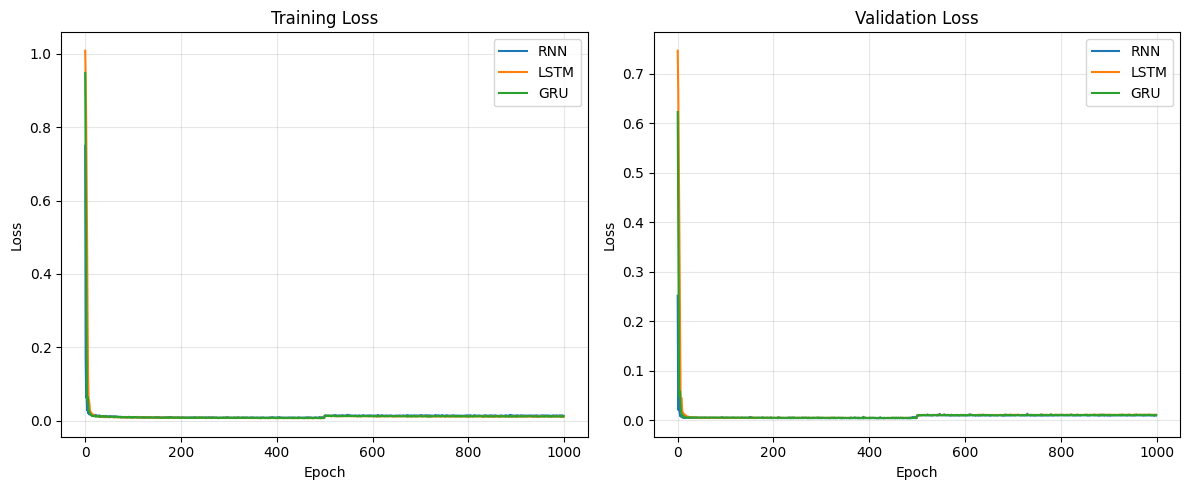

In [249]:
# Plot training and validation loss curves for all models
plt.figure(figsize=(12, 5))

# Training loss
plt.subplot(1, 2, 1)
for model_name, h in history.items():
    if len(h["train_loss"]) > 0:
        plt.plot(h["train_loss"], label=model_name)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Validation loss (stored as test_loss in history)
plt.subplot(1, 2, 2)
for model_name, h in history.items():
    if len(h["test_loss"]) > 0:
        plt.plot(h["test_loss"], label=model_name)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




In [251]:
# Compare latest market close vs model predictions (Apple + Tesla, all models)

# def fetch_latest_feature_row(ticker, feature_cols, period="10d"):
# 	df = yf.download(ticker, period=period, interval="1d", progress=False, auto_adjust=False)

# 	if df.empty:
# 		raise ValueError(f"No data returned for {ticker}")

# 	# Handle possible MultiIndex columns from yfinance
# 	if isinstance(df.columns, pd.MultiIndex):
# 		df.columns = df.columns.get_level_values(0)

# 	required_base = ["Close", "High", "Low", "Open", "Volume"]
# 	missing = [c for c in required_base if c not in df.columns]
# 	if missing:
# 		raise ValueError(f"{ticker}: missing columns {missing}")

# 	latest = df[required_base].dropna().tail(1).copy()
# 	if latest.empty:
# 		raise ValueError(f"{ticker}: latest row is empty after dropna")

# 	dt = pd.to_datetime(latest.index)
# 	latest["Month"] = dt.month
# 	latest["Day"] = dt.day
# 	latest["weekday"] = dt.weekday
# 	latest["quarter"] = dt.quarter

# 	latest["month_sin"] = np.sin(2 * np.pi * latest["Month"] / 12)
# 	latest["month_cos"] = np.cos(2 * np.pi * latest["Month"] / 12)
# 	latest["day_sin"] = np.sin(2 * np.pi * latest["Day"] / 31)
# 	latest["day_cos"] = np.cos(2 * np.pi * latest["Day"] / 31)
# 	latest["weekday_sin"] = np.sin(2 * np.pi * latest["weekday"] / 7)
# 	latest["weekday_cos"] = np.cos(2 * np.pi * latest["weekday"] / 7)
# 	latest["quarter_sin"] = np.sin(2 * np.pi * latest["quarter"] / 4)
# 	latest["quarter_cos"] = np.cos(2 * np.pi * latest["quarter"] / 4)

# 	latest = latest.drop(columns=["Month", "Day", "weekday", "quarter"])
# 	latest = latest[feature_cols]  # enforce training column order
# 	latest_date = latest.index[0].date()
# 	latest_close = float(latest["Close"].iloc[0])

# 	return latest, latest_date, latest_close


# def predict_close_price(model, latest_features_df, fitted_scaler, device_obj):
# 	x_scaled = fitted_scaler.transform(latest_features_df.values)  # shape: (1, 13)
# 	x_tensor = torch.FloatTensor(x_scaled).unsqueeze(1).to(device_obj)  # (1, 1, 13)

# 	model.eval()
# 	with torch.no_grad():
# 		pred_scaled, _ = model(x_tensor)
# 		pred_scaled = float(pred_scaled.squeeze().item())

# 	# Inverse transform only "Close" using scaler stats (column 0)
# 	close_mean = fitted_scaler.mean_[0]
# 	close_std = np.sqrt(fitted_scaler.var_[0])
# 	pred_close = pred_scaled * close_std + close_mean
# 	return pred_close


# feature_columns = list(tesla_data.columns)

# # Rebuild scalers to match how each dataset was standardized
# tesla_scaler_live = StandardScaler().fit(tesla_data[feature_columns])
# apple_scaler_live = StandardScaler().fit(apple_data[feature_columns])

# models = {
# 	"RNN": rnn_model,
# 	"LSTM": lstm_model,
# 	"GRU": gru_model
# }

# tickers_info = {
# 	"Apple": {"ticker": "AAPL", "scaler": apple_scaler_live},
# 	"Tesla": {"ticker": "TSLA", "scaler": tesla_scaler_live}
# }

# rows = []
# for company, info in tickers_info.items():
# 	latest_features, latest_date, actual_close = fetch_latest_feature_row(
# 		info["ticker"], feature_columns
# 	)

# 	row = {
# 		"Company": company,
# 		"Ticker": info["ticker"],
# 		"Date": latest_date,
# 		"Actual_Close": actual_close
# 	}

# 	for model_name, model_obj in models.items():
# 		pred_close = predict_close_price(model_obj, latest_features, info["scaler"], device)
# 		row[f"{model_name}_Pred"] = pred_close
# 		row[f"{model_name}_Error"] = pred_close - actual_close

# 	rows.append(row)

# results_df = pd.DataFrame(rows)
# print(results_df)

# # Plot: actual vs predictions for each company
# fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# for ax, (_, r) in zip(axes, results_df.iterrows()):
# 	labels = ["Actual", "RNN", "LSTM", "GRU"]
# 	values = [
# 		r["Actual_Close"],
# 		r["RNN_Pred"],
# 		r["LSTM_Pred"],
# 		r["GRU_Pred"]
# 	]

# 	ax.bar(labels, values, color=["black", "tab:blue", "tab:orange", "tab:green"], alpha=0.85)
# 	ax.set_title(f"{r['Company']} ({r['Ticker']}) - {r['Date']}")
# 	ax.set_ylabel("Close Price")
# 	ax.grid(axis="y", alpha=0.25)

# plt.tight_layout()
# plt.show()
